# 05_01. Cell type vs tissue: which explains more of isoform diversity?

A proper **variance partition** on the crossed (cell type × tissue) design, avoiding the confounds of the marginal per-gene variance heuristic (04_04 §8 / 04_05 §9): those compare `Var` across cell types vs across tissues *separately*, which double-counts the shared structure (cell types are sampled from different tissues) and isn't corrected for the unequal number of levels (~cell types ≫ tissues).

**Unit of analysis.** Single cells are too sparse to define per-cell isoform diversity (usually 1–2 molecules/gene/cell), so the analysis is at the group level: for each gene, build the **cell-type × tube pseudobulk** mean isoform-fraction profiles (one row per (cell type, tube) with ≥ `MIN_CELLS_COMBO` expressing cells; each tube's tissue is its tissue label), then partition their variation with **both factors in one additive model** (`celltype + tissue`).

**Two questions, methods run side by side:**
1. **Composition — which isoforms are used → PERMANOVA (Bray–Curtis).** Distance-based SS partition (McArdle & Anderson 2001). Reported two ways: the raw `R²` per factor (**descriptive only — not df-adjusted**, so it favours whichever factor has more levels) *and* a **df-corrected partial ω²** per factor (the fair comparison; see the caveat in §2).
2. **Diversity level — how even is usage → two-way ANOVA (type-II SS), ω² per factor.** On each profile's Shannon entropy; df-corrected **ω²** so the cell types and tissues are comparable.

**Design note.** Pseudobulk unit is (cell type, **tube**). With ≥ 2 tubes per tissue (true for all 26 tissues here), tubes are within-tissue biological replicates, so the additive `celltype + tissue` model's residual is genuine **between-tube (between-donor)** variation rather than conflated interaction+noise, and tissue is no longer pseudoreplicated (the earlier (cell type, tissue) design had one row per combo → no replication). Both factors must vary (≥ 2 cell types **and** ≥ 2 tissues) with enough (tube-level) combos for positive residual df.

**Run on a compute node** (`sbatch`/nbconvert) — the pseudobulk build sweeps every cell-type × tube combination.

In [1]:
import logging
logging.getLogger("fontTools").setLevel(logging.WARNING)

import os
_r = os.path.abspath(".")
while _r != os.path.dirname(_r) and not os.path.exists(os.path.join(_r, ".notebooks_root")):
    _r = os.path.dirname(_r)
os.chdir(_r if os.path.exists(os.path.join(_r, ".notebooks_root")) else "/oak/stanford/groups/quake/mmantri/group.quake/tabula_longread/notebooks")  # cd to notebooks/ root (marked .notebooks_root); relocation-proof

import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.legend as _mlegend
import matplotlib.pyplot as plt
from scipy.sparse import issparse, csc_matrix
from scipy.spatial.distance import pdist, squareform
from scipy.stats import wilcoxon
import warnings, os, gc
warnings.filterwarnings('ignore')
gc.enable()

BASEDIR = "./../pacbio"
H5AD_DIR = f"{BASEDIR}/h5ads"
CSVS_DIR = "./../csvs"
os.makedirs("figures", exist_ok=True)

# --- filters ---
MIN_CELLS_COMBO = 10   # min expressing cells per (gene, cell type, tissue) combo
MIN_COMBOS      = 2    # min pseudobulk combos per gene
MIN_ISOFORMS    = 2

# preferred plot formatting
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['Arial'] + matplotlib.rcParams['font.sans-serif']
# Mathtext (anything in $...$) otherwise falls back to DejaVu Sans, so Greek letters,
# superscripts and subscripts render in a different family from the surrounding Arial.
# "custom" + the four Arial families keeps the whole figure in one typeface.
matplotlib.rcParams['mathtext.fontset'] = 'custom'
matplotlib.rcParams['mathtext.rm'] = 'Arial'
matplotlib.rcParams['mathtext.it'] = 'Arial:italic'
matplotlib.rcParams['mathtext.bf'] = 'Arial:bold'
TICK_LEN = 2.0
TICK_LABEL_PAD = 1.5
AXIS_LABEL_PAD = 1.5
PANEL_TITLE_PAD = 3.0   # pass explicitly: ax.set_title(..., pad=PANEL_TITLE_PAD)
plt.rcParams.update({
    "font.size": 6,
    "axes.titlesize": 6,
    "axes.labelsize": 6,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 6,
    "legend.title_fontsize": 6,
    "legend.labelspacing": 0.1,
    "legend.borderpad": 0.3,
    "legend.handletextpad": 0.2,
    "figure.titlesize": 6,
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "figure.titleweight": "bold",
    "xtick.major.size": TICK_LEN,
    "ytick.major.size": TICK_LEN,
    "xtick.major.pad": TICK_LABEL_PAD,
    "ytick.major.pad": TICK_LABEL_PAD,
    "axes.labelpad": AXIS_LABEL_PAD,
    "axes.titlepad": PANEL_TITLE_PAD,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

# Legend-title weight has no rcParam -> make every legend title bold by default.
if not getattr(_mlegend.Legend, "_bold_title_patched", False):
    _orig_set_title = _mlegend.Legend.set_title
    def _bold_set_title(self, title, prop=None):
        res = _orig_set_title(self, title, prop=prop)
        self.get_title().set_fontweight("bold")
        return res
    _mlegend.Legend.set_title = _bold_set_title
    _mlegend.Legend._bold_title_patched = True


def shannon(p):
    p = np.asarray(p, dtype=float); p = p[p > 0]
    if p.size == 0:
        return 0.0
    p = p / p.sum()
    return float(-np.sum(p * np.log2(p)))


RENYI_ALPHA = 2      # collision entropy, matching 04_05 / 04_06 so Figure 4 is one metric


def renyi(p, alpha=RENYI_ALPHA):
    """Renyi entropy H_alpha in bits; alpha=2 is collision entropy, -log2(sum p^2).

    The diversity arm was built on Shannon while Fig 4A/4B plot Renyi, so the figure switched
    metric mid-way without saying so. Renyi is now the reported metric and Shannon is kept as a
    concordance check. They are NOT interchangeable in principle: alpha=2 is dominated by the
    most-used isoforms, Shannon weights rare ones more, so on sparse pseudobulk profiles the two
    can order genes differently -- which is exactly why both are computed rather than swapped.
    """
    p = np.asarray(p, dtype=float)
    p = p[p > 0]
    if p.size == 0:
        return 0.0
    p = p / p.sum()
    if abs(alpha - 1.0) < 1e-12:
        return float(-np.sum(p * np.log2(p)))      # limit case is Shannon
    return float(np.log2(np.sum(p ** alpha)) / (1.0 - alpha))


def dummies(labels):
    """Drop-first dummy coding (no intercept) for a categorical factor -> n x (L-1)."""
    return pd.get_dummies(pd.Categorical(labels), drop_first=True).to_numpy(dtype=float)

# reload figure_paths: a live kernel caches FIG_MAP
import importlib
import figure_paths
importlib.reload(figure_paths)
from figure_paths import figpath  # routes figures/ -> figures/figureN/ via FIG_MAP


## 1. Load and build per-gene cell-type × tube pseudobulk profiles

Load the transcripts `_with_isofrac` object. For every (cell type, **tube_id**) combination, slice its cells once and record, for each gene with ≥ `MIN_CELLS_COMBO` expressing cells, the mean isoform-fraction vector → one profile row per (gene, cell type, tube), labelled with that tube's tissue. Multiple tubes per tissue give the within-tissue biological replication the §2 partition tests against.

In [2]:
adata = sc.read_h5ad(f"{H5AD_DIR}/all_samples_pacbio_recollapsed_raw_counts_ensemblids_bc_anndata_preprocessed_with_isofrac.h5ad")
gene_col = "associated_gene" if "associated_gene" in adata.var.columns else "gene_name"
print(f"adata: {adata.shape}, gene_col={gene_col}")

frac_csr = adata.layers["isoform_fraction"]
frac_csr = frac_csr.tocsr() if issparse(frac_csr) else frac_csr

genes = adata.var[gene_col].values
unique_genes, gene_indices = np.unique(genes, return_inverse=True)
n_genes_unique = len(unique_genes)
gene_col_indices = [np.where(gene_indices == g)[0] for g in range(n_genes_unique)]
# isoform -> gene indicator (for per-gene expressing-cell counts)
iso_to_gene = csc_matrix((np.ones(len(genes), dtype=np.float32),
                          (np.arange(len(genes)), gene_indices)),
                         shape=(len(genes), n_genes_unique))

# MAIN result uses FINE cell types (cell_ontology_class). This is what the manuscript quotes:
# the headline partial omega^2 of 0.051 (cell type) vs 0.054 (tissue) is the fine-resolution
# number -- means over the 10,850 genes in celltype_vs_tissue_variance_partition.csv,
# Renyi diversity is 0.062 vs 0.047 (Shannon 0.064 vs 0.042).
# The section-4 ladder reports the broad-class values (0.038 vs 0.090) as the comparison. Pseudobulk unit = (cell type, TUBE): tubes are biological replicates WITHIN a
# tissue (>=2 tubes/tissue for all 26 tissues), so the additive celltype+tissue partition's
# residual is genuine between-tube (between-donor) variation instead of conflated
# interaction+noise, and tissue is no longer pseudoreplicated.
#
# Note on the section-2 caveat: at FINE resolution the cell-type factor contributes far MORE
# dummy columns (144 cell types vs 26 tissues), so raw R2 is strongly df-inflated in cell
# type's favour -- that inflation is exactly why the raw arm reports 77.6% of genes favouring
# cell type while the adjusted arm reports a near-tie. The df-adjusted partial omega^2 arm
# corrects for it and is the arm to quote; raw R2 is retained only to show the artefact's size.
CT_COL = "cell_ontology_class"
pop = adata.obs[CT_COL].values
tub = adata.obs["tube_id"].astype(str).values
tis = adata.obs["tissue"].astype(str).values
don = adata.obs["donor"].astype(str).values
cell_types = sorted(c for c in np.unique(pop) if c != "unknown")
tubes = sorted(np.unique(tub))
tube_tissue = dict(zip(tub, tis))                       # each tube belongs to exactly one tissue
tube_donor = dict(zip(tub, don))                        # and to exactly one donor
tissues = sorted(set(tube_tissue.values()))
print(f"CT_COL={CT_COL}: {n_genes_unique} genes, {len(cell_types)} cell types, "
      f"{len(tubes)} tubes across {len(tissues)} tissues")

# gene index -> list of (celltype, tissue, donor, TUBE, mean_IF_vector); one row per
# (celltype, tube). The tube id is kept because the corrected model needs it as a
# blocking factor -- see the two-level section.
# tissue label = the tube's tissue (so a tissue with k tubes contributes up to k replicate rows).
gene_profiles = {g: [] for g in range(n_genes_unique)}
n_combos_seen = 0
for ct in cell_types:
    ct_mask = (pop == ct)
    if ct_mask.sum() < MIN_CELLS_COMBO:
        continue
    for tube in tubes:
        m = ct_mask & (tub == tube)
        if m.sum() < MIN_CELLS_COMBO:
            continue
        n_combos_seen += 1
        frac_sub = frac_csr[m, :]
        col_sums = np.asarray(frac_sub.sum(axis=0)).ravel()
        gene_expr = (frac_sub > 0).astype(np.float32) @ iso_to_gene
        n_expr_per_gene = np.asarray((gene_expr > 0).sum(axis=0)).ravel()
        # genes with enough expressing cells in this (celltype, tube) and >= 2 isoforms
        genes_ok = np.where(n_expr_per_gene >= MIN_CELLS_COMBO)[0]
        ti = tube_tissue[tube]
        for g in genes_ok:
            cols = gene_col_indices[g]
            if len(cols) < MIN_ISOFORMS:
                continue
            gene_profiles[g].append((ct, ti, tube_donor[tube], tube,
                                     col_sums[cols] / n_expr_per_gene[g]))

n_genes_with_profiles = sum(1 for v in gene_profiles.values() if len(v) >= MIN_COMBOS)
print(f"Non-empty (cell type x tube) combos: {n_combos_seen}")
print(f"Genes with >= {MIN_COMBOS} tube-level pseudobulk combos: {n_genes_with_profiles}")

adata: (203311, 478192), gene_col=gene_name
CT_COL=cell_ontology_class: 26940 genes, 144 cell types, 60 tubes across 26 tissues
Non-empty (cell type x tube) combos: 640
Genes with >= 2 tube-level pseudobulk combos: 24514


## 2. Variance partition per gene (PERMANOVA R² + partial ω², ANOVA ω²)

For each gene, build the design from its profiles' cell-type and tissue labels (additive, drop-first dummy coding) and run:
- **`permanova_r2`** — Bray–Curtis distance between profiles → Gower-centered matrix `G = −½ J D² J` → type-II SS via projection-matrix traces (`trace(H_full·G) − trace(H_reduced·G)`). Returns both the raw `R²_celltype`/`R²_tissue`/`R²_residual` **and** a df-corrected **partial ω²** per factor (composition drivers).
- **`anova_omega2`** — type-II SS of each profile's Shannon entropy on the same design → **ω²** per factor (df-corrected diversity-level drivers).

Genes need both factors varying (≥ 2 cell types **and** ≥ 2 tissues) and enough combos for positive residual df. **Profiles are at (cell type, tube) resolution** — multiple tubes per tissue provide within-tissue biological replication, so the additive model's residual is genuine between-tube (between-donor) variation rather than conflated interaction+noise (the previous (cell type, tissue) design had one row per combo and pseudoreplicated tissue). The tissue main effect is now tested against that between-tube spread, so its ω² is a fairer estimate.

> **⚠️ Caveat — raw R² is not degrees-of-freedom-adjusted, so it favours whichever factor has more levels.** A factor contributing more dummy columns to the design mechanically explains more variance, independent of any real effect. When cell type has many more levels than tissue, `R²_celltype` is inflated and the "cell type wins" rate is overstated (empirically: the raw-R² cell-type win rate collapses toward 50% once the two factors have a comparable number of levels, and `R²_diff` correlates with `n_celltypes − n_tissues`). The **diversity-level ω²** already corrects for this via a df penalty; to put the **composition** arm on the same footing we also report a **partial ω²** for PERMANOVA — the identical `(SS − df·MS_resid)/(SS_total + MS_resid)` estimator applied in the Gower SS space. Compare `ω²` across both arms for the fair conclusion; treat the raw `R²` as descriptive only. (Note: raw type-II `R²_ct + R²_ti + R²_res` sums to `< 1` — the shared, correlated-factor covariance is left unattributed by design.)

In [3]:
def _hat(cols, n):
    """Projection (hat) matrix for design [intercept | *cols]."""
    X = np.hstack([np.ones((n, 1))] + cols)
    return X @ np.linalg.pinv(X.T @ X) @ X.T


def permanova_r2(Y, C, T):
    """Bray-Curtis PERMANOVA type-II partition (McArdle & Anderson 2001).

    Returns (R2_ct, R2_ti, R2_res, w2comp_ct, w2comp_ti): the first three are the raw
    (un-adjusted) R² per factor; the last two are a **df-corrected partial omega^2** per
    factor — the SAME estimator as anova_omega2, applied in the Gower SS space. Raw R² is
    NOT adjusted for degrees of freedom, so whichever factor has more levels is mechanically
    favoured; the partial omega^2 penalises each factor by its df, putting composition on
    equal footing with the diversity-level (entropy) arm. See the caveat note above."""
    n = Y.shape[0]
    D2 = squareform(pdist(Y, metric="braycurtis")) ** 2
    J = np.eye(n) - np.ones((n, n)) / n
    G = -0.5 * J @ D2 @ J
    tot = float(np.trace(G))
    if tot <= 0:
        return None
    ss_full = float(np.trace(_hat([C, T], n) @ G))
    ss_C = max(ss_full - float(np.trace(_hat([T], n) @ G)), 0.0)     # celltype after tissue
    ss_T = max(ss_full - float(np.trace(_hat([C], n) @ G)), 0.0)     # tissue after celltype
    ss_res = max(tot - ss_full, 0.0)
    R2 = (ss_C / tot, ss_T / tot, ss_res / tot)

    # df-corrected partial omega^2 (mirror of anova_omega2, in Gower space)
    dfC, dfT = C.shape[1], T.shape[1]
    dfR = n - 1 - dfC - dfT
    if dfR <= 0:
        return R2 + (None, None)
    msR = ss_res / dfR
    w2C = max((ss_C - dfC * msR) / (tot + msR), 0.0)
    w2T = max((ss_T - dfT * msR) / (tot + msR), 0.0)
    return R2 + (w2C, w2T)


def anova_omega2(h, C, T):
    """Two-way (additive) type-II ANOVA on scalar h -> omega^2 per factor."""
    n = h.shape[0]
    h = h.reshape(-1, 1)

    def rss(cols):
        X = np.hstack([np.ones((n, 1))] + cols)
        b, *_ = np.linalg.lstsq(X, h, rcond=None)
        r = h - X @ b
        return float((r * r).sum())

    tss = float(((h - h.mean()) ** 2).sum())
    if tss <= 0:
        return 0.0, 0.0
    dfC, dfT = C.shape[1], T.shape[1]
    dfR = n - 1 - dfC - dfT
    if dfR <= 0:
        return None
    rss_full = rss([C, T])
    ss_C = rss([T]) - rss_full
    ss_T = rss([C]) - rss_full
    msR = rss_full / dfR
    w2C = (ss_C - dfC * msR) / (tss + msR)
    w2T = (ss_T - dfT * msR) / (tss + msR)
    return max(w2C, 0.0), max(w2T, 0.0)


# --- Additive type-II partition for an ARBITRARY factor set -------------------------------
# Generalisations of permanova_r2 / anova_omega2 above. The two-factor originals are kept
# untouched because the resolution-ladder section still calls them with (C, T).
def permanova_r2_multi(Y, factors, names):
    """Type-II Bray-Curtis PERMANOVA over an additive model of `factors`."""
    n = Y.shape[0]
    D2 = squareform(pdist(Y, metric="braycurtis")) ** 2
    J = np.eye(n) - np.ones((n, n)) / n
    G = -0.5 * J @ D2 @ J
    tot = float(np.trace(G))
    if tot <= 0:
        return None
    dfs = [f.shape[1] for f in factors]
    dfR = n - 1 - sum(dfs)
    if dfR <= 0:
        return None
    ss_full = float(np.trace(_hat(factors, n) @ G))
    ss_res = max(tot - ss_full, 0.0)
    msR = ss_res / dfR
    out = {"R2_residual": ss_res / tot, "df_residual": dfR}
    for k, nm in enumerate(names):
        others = [f for j, f in enumerate(factors) if j != k]
        ss_k = max(ss_full - float(np.trace(_hat(others, n) @ G)), 0.0)
        out[f"R2_{nm}"] = ss_k / tot
        out[f"omega2comp_{nm}"] = max((ss_k - dfs[k] * msR) / (tot + msR), 0.0)
    return out


def permanova_interaction_split(Y, cts, tis_, extra_factors):
    """Composition-arm analogue of anova_interaction_split: split the PERMANOVA residual into
    celltype-by-tissue INTERACTION and UNMODELLED VARIATION, in the same Gower SS space the R2 values use.

    Identical logic to the ANOVA version, applied to trace(H @ G) instead of a scalar RSS: cell
    means absorb both main effects and their interaction, so the SS they explain BEYOND the
    additive model is the interaction, and what remains unexplained is unmodelled within-cell variation.
    Needs a replicated (celltype, tissue) cell; returns None otherwise.
    """
    n = Y.shape[0]
    D2 = squareform(pdist(Y, metric="braycurtis")) ** 2
    J = np.eye(n) - np.ones((n, n)) / n
    G = -0.5 * J @ D2 @ J
    tot = float(np.trace(G))
    if tot <= 0:
        return None
    cells = pd.factorize(pd.MultiIndex.from_arrays([np.asarray(cts), np.asarray(tis_)]))[0]
    CM = dummies(cells)
    X_cm = np.hstack([np.ones((n, 1)), CM] + list(extra_factors))
    X_add = np.hstack([np.ones((n, 1)), dummies(cts), dummies(tis_)] + list(extra_factors))
    rank_cm, rank_add = int(np.linalg.matrix_rank(X_cm)), int(np.linalg.matrix_rank(X_add))
    df_err = n - rank_cm
    if df_err <= 0:
        return None
    ss_cm = float(np.trace(_hat([CM] + list(extra_factors), n) @ G))
    ss_add = float(np.trace(_hat([dummies(cts), dummies(tis_)] + list(extra_factors), n) @ G))
    return {"R2_interaction": max(ss_cm - ss_add, 0.0) / tot,
            "R2_error": max(tot - ss_cm, 0.0) / tot,
            "df_interaction_comp": rank_cm - rank_add,
            "df_error_comp": df_err}


def anova_omega2_multi(h, factors, names):
    """Additive type-II ANOVA on scalar h -> partial omega^2 per factor."""
    n = h.shape[0]
    h = h.reshape(-1, 1)

    def rss(cols):
        X = np.hstack([np.ones((n, 1))] + list(cols))
        bb, *_ = np.linalg.lstsq(X, h, rcond=None)
        r = h - X @ bb
        return float((r * r).sum())

    tss = float(((h - h.mean()) ** 2).sum())
    dfs = [f.shape[1] for f in factors]
    dfR = n - 1 - sum(dfs)
    if dfR <= 0:
        return None
    if tss <= 0:
        return {f"omega2_{nm}": 0.0 for nm in names}
    rss_full = rss(factors)
    msR = rss_full / dfR
    # Report the RAW eta^2 alongside the df-adjusted omega^2, mirroring what the composition
    # arm does with R2 vs omega2comp. Without it the diversity arm asks the reader to take the
    # correction on trust: there is no way to see how much of the cell-type/tissue gap is signal
    # and how much is the adjustment, which on the composition side turned 77.6% of genes
    # favouring cell type into a near-tie. Same type-II SS convention as permanova_r2_multi, so
    # eta^2 components do NOT sum to 1 with the residual (shared variance is removed twice).
    out = {"eta2_residual": rss_full / tss}
    for k, nm in enumerate(names):
        others = [f for j, f in enumerate(factors) if j != k]
        ss_k = max(rss(others) - rss_full, 0.0)
        out[f"eta2_{nm}"] = ss_k / tss
        out[f"omega2_{nm}"] = max((ss_k - dfs[k] * msR) / (tss + msR), 0.0)
    return out


def anova_interaction_split(h, cts, tis_, extra_factors):
    """Split the additive model's residual into celltype-by-tissue INTERACTION and UNMODELLED VARIATION.

    An additive celltype + tissue model leaves those two conflated in one residual. They
    separate only where the design REPLICATES a (celltype, tissue) cell, which the tube-level
    pseudobulk supplies: two tubes of the same tissue contributing the same cell type are two
    independent draws from the same cell. Fitting CELL MEANS (one parameter per occupied
    celltype-by-tissue cell) absorbs the main effects AND their interaction, so what is left is
    unmodelled within-cell variation; the gap between the additive and cell-means fits is the interaction.

    Returns None when no cell is replicated (df_error <= 0), which is the common case in a
    sparse design -- the caller records how many genes were estimable.
    """
    n = h.shape[0]
    h = h.reshape(-1, 1)
    tss = float(((h - h.mean()) ** 2).sum())
    if tss <= 0:
        return None
    # Integer codes for the (celltype, tissue) cell. NOT a concatenated string: pandas
    # truncates categorical labels at a NUL separator, which silently collapsed "A\x00T1" and
    # "A\x00T2" into one category and left the cell-means design rank-deficient (it then had
    # FEWER columns than the additive model, so df_interaction came out negative and every
    # interaction measured zero).
    cells = pd.factorize(pd.MultiIndex.from_arrays([np.asarray(cts), np.asarray(tis_)]))[0]
    from collections import Counter
    n_rep_cells = sum(1 for v in Counter(cells.tolist()).values() if v > 1)

    def _rss_rank(cols):
        X = np.hstack([np.ones((n, 1))] + list(cols))
        bb, *_ = np.linalg.lstsq(X, h, rcond=None)
        r = h - X @ bb
        return float((r * r).sum()), int(np.linalg.matrix_rank(X))

    rss_add, rank_add = _rss_rank([dummies(cts), dummies(tis_)] + list(extra_factors))
    rss_cm, rank_cm = _rss_rank([dummies(cells)] + list(extra_factors))
    df_err = n - rank_cm
    if df_err <= 0:
        return None
    return {"eta2_interaction": max(rss_add - rss_cm, 0.0) / tss,
            "eta2_error": rss_cm / tss,
            "df_interaction": rank_cm - rank_add,
            "df_error": df_err,
            "n_replicated_cells": n_rep_cells}


import os
from concurrent.futures import ProcessPoolExecutor
try:
    from threadpoolctl import threadpool_limits
except Exception:
    from contextlib import nullcontext
    def threadpool_limits(*a, **k):
        return nullcontext()

# Per-gene variance partition is independent per gene, so we distribute genes across a
# fork-based process pool. Workers inherit gene_profiles / the estimator functions via
# copy-on-write (only a list of gene indices is sent). Genes are split into CONTIGUOUS
# chunks and results concatenated in chunk order, so the record order is identical to the
# serial loop -> bit-identical DataFrame, CSV, and downstream summaries. Worker count is
# clamped to the true CPU allocation and BLAS pinned to 1 thread/worker (the PERMANOVA
# pinv/lstsq call BLAS) to avoid the N_procs x all-core-BLAS oversubscription blowup.
# Guard: `build` now emits 5-tuples (celltype, tissue, donor, tube, vector). If this cell
# is run against a kernel that still holds profiles from an older `build`, the workers
# fail with an opaque "tuple index out of range" from inside the process pool.
_ar = len(next(v[0] for v in gene_profiles.values() if v))
assert _ar == 5, (f"gene_profiles holds {_ar}-tuples, expected 5 -- re-run the `build` "
                  f"cell in section 1 before this one")

def _partition_one_gene(g):
    """Additive celltype + tissue + DONOR partition on this gene's (celltype, tube) profiles.

    Donor was previously unmodelled, so donor-level variation fell into the residual together
    with the celltype-by-tissue interaction. It costs degrees of freedom (n_donors - 1), so
    with MIN_COMBOS profiles some genes that survived the two-factor model now fail the
    residual-df test and drop out -- the printed gene count shows how many."""
    profs = gene_profiles[g]
    if len(profs) < MIN_COMBOS:
        return None
    cts = [p[0] for p in profs]
    tis_ = [p[1] for p in profs]
    dons = [p[2] for p in profs]
    if len(set(cts)) < 2 or len(set(tis_)) < 2:
        return None
    Y = np.asarray([p[4] for p in profs], dtype=float)
    C, T, D = dummies(cts), dummies(tis_), dummies(dons)
    facs, names = [C, T, D], ["celltype", "tissue", "donor"]
    if len(profs) - 1 - sum(f.shape[1] for f in facs) <= 0:
        return None
    pr = permanova_r2_multi(Y, facs, names)
    if pr is None:
        return None
    # Renyi is the REPORTED diversity metric (matches Fig 4A/4B); Shannon is retained in the
    # same pass as a concordance check. The ANOVA is negligible next to the PERMANOVA, so the
    # second metric is nearly free.
    hvec = np.asarray([shannon(v) for v in Y])
    rvec = np.asarray([renyi(v) for v in Y])
    aw = anova_omega2_multi(hvec, facs, names)
    if aw is None:
        return None
    awr = anova_omega2_multi(rvec, facs, names)
    # interaction vs unmodelled variation, where replication allows it (None -> columns stay NaN).
    # Done for BOTH arms so neither residual is left as an undifferentiated lump.
    ai = anova_interaction_split(hvec, cts, tis_, [D])
    air = anova_interaction_split(rvec, cts, tis_, [D])
    pi = permanova_interaction_split(Y, cts, tis_, [D])
    rec = {"gene": unique_genes[g], "n_combos": len(profs),
           "n_celltypes": len(set(cts)), "n_tissues": len(set(tis_)),
           "n_donors": len(set(dons)), "n_isoforms": Y.shape[1]}
    rec.update(pr)
    rec.update(aw)
    if awr is not None:            # renyi columns carry an explicit "renyi" tag
        rec.update({k.replace("omega2_", "omega2renyi_").replace("eta2_", "eta2renyi_"): v
                    for k, v in awr.items()})
    if ai is not None:
        rec.update(ai)
    if air is not None:            # dfs are identical to the Shannon split (same design)
        rec.update({"eta2renyi_interaction": air["eta2_interaction"],
                    "eta2renyi_error": air["eta2_error"]})
    if pi is not None:
        rec.update(pi)
    return rec


def _partition_gene_chunk(g_list):
    return [r for r in (_partition_one_gene(g) for g in g_list) if r is not None]

_keys = list(gene_profiles.keys())
_n_workers = max(1, min(len(_keys), len(os.sched_getaffinity(0))))
_chunks = [[int(g) for g in c] for c in np.array_split(_keys, _n_workers) if len(c)]
print(f"Variance partition over {len(_keys)} candidate genes on {_n_workers} worker process(es)")

records = []
with threadpool_limits(limits=1):
    if _n_workers == 1:
        for _ch in _chunks:
            records.extend(_partition_gene_chunk(_ch))
    else:
        with ProcessPoolExecutor(max_workers=_n_workers) as _ex:
            for _recs in _ex.map(_partition_gene_chunk, _chunks):
                records.extend(_recs)

res = pd.DataFrame(records)
res["R2_diff"] = res["R2_celltype"] - res["R2_tissue"]                          # raw composition (df-inflated)
res["omega2comp_diff"] = res["omega2comp_celltype"] - res["omega2comp_tissue"]  # df-adjusted composition
res["omega2_diff"] = res["omega2_celltype"] - res["omega2_tissue"]              # diversity, Shannon
res["omega2renyi_diff"] = res["omega2renyi_celltype"] - res["omega2renyi_tissue"]  # diversity, Renyi (reported)
print("mean omega^2 (composition): " + " | ".join(
    f"{n} {res[f'omega2comp_{n}'].mean():.4f}" for n in ("celltype", "tissue", "donor")))
print("mean omega^2 (diversity, RENYI a=2, reported): " + " | ".join(
    f"{n} {res[f'omega2renyi_{n}'].mean():.4f}" for n in ("celltype", "tissue", "donor")))
print("mean omega^2 (diversity, Shannon, concordance): " + " | ".join(
    f"{n} {res[f'omega2_{n}'].mean():.4f}" for n in ("celltype", "tissue", "donor")))
_agree = (np.sign(res["omega2renyi_diff"]) == np.sign(res["omega2_diff"])).mean()
print(f"  Renyi vs Shannon: Spearman(omega2 diff) "
      f"{res['omega2renyi_diff'].corr(res['omega2_diff'], method='spearman'):+.3f} | "
      f"same winner in {_agree*100:.1f}% of genes")
print(f"median residual R2: {res['R2_residual'].median():.3f} | "
      f"median residual df: {res['df_residual'].median():.0f}")
# RAW eta^2 on the REPORTED metric (Renyi), so this line matches the figures. The Shannon
# columns stay in `res` for the concordance statement but are no longer printed anywhere.
_P = "eta2renyi_" if "eta2renyi_celltype" in res.columns else "eta2_"
print(f"mean eta^2 (diversity, RAW, {'Rényi' if _P.endswith('renyi_') else 'Shannon'}): " + " | ".join(
    f"{n} {res[f'{_P}{n}'].mean():.4f}" for n in ("celltype", "tissue", "donor"))
    + f" | residual {res[f'{_P}residual'].mean():.4f}")
if "eta2_interaction" in res.columns:
    _est = res["eta2_interaction"].notna()
    print(f"\ncelltype-by-tissue INTERACTION separable in {int(_est.sum()):,}/{len(res):,} genes "
          f"({_est.mean()*100:.1f}%) -- needs a replicated (celltype, tissue) cell")
    if _est.any():
        _e = res.loc[_est]
        print(f"  of the additive residual (mean eta^2 {_e['eta2_residual'].mean():.4f}): "
              f"interaction {_e['eta2_interaction'].mean():.4f} | "
              f"unmodelled {_e['eta2_error'].mean():.4f}")
        print(f"  median replicated cells/gene {_e['n_replicated_cells'].median():.0f} | "
              f"median df_interaction {_e['df_interaction'].median():.0f} | "
              f"median df_error {_e['df_error'].median():.0f}")
        print("  NOTE low df_error means the split is noisy per gene; read the AVERAGE, not a "
              "single gene's value.")
        # per-gene share, more robust than the ratio of the two means printed above
        _ic, _uc = f"{_P}interaction", f"{_P}error"
        if _ic in res.columns and res[_ic].notna().any():
            _s = res.loc[res[_ic].notna()]
            _share = _s[_ic] / (_s[_ic] + _s[_uc]).clip(lower=1e-12)
            print(f"  interaction as a share of (interaction + unmodelled): median {_share.median():.3f}")
            print("    high -> the additive model is missing real celltype-by-tissue structure;")
            print("    low  -> the leftover is mostly between-tube variation and the additive model fits.")
if "R2_interaction" in res.columns and res["R2_interaction"].notna().any():
    _c = res[res["R2_interaction"].notna()]
    print(f"\ncomposition arm, same split ({len(_c):,} genes):")
    print(f"  of the additive residual (mean R2 {_c['R2_residual'].mean():.4f}): "
          f"interaction {_c['R2_interaction'].mean():.4f} | "
          f"unmodelled {_c['R2_error'].mean():.4f}")
_out = f"{CSVS_DIR}/celltype_vs_tissue_variance_partition.csv"
res.to_csv(_out, index=False)
print(f"Analysed {len(res)} genes | saved {_out}")
res.head(10)

Variance partition over 26940 candidate genes on 16 worker process(es)
mean omega^2 (composition): celltype 0.0509 | tissue 0.0539 | donor 0.0448
mean omega^2 (diversity, RENYI a=2, reported): celltype 0.0616 | tissue 0.0468 | donor 0.0396
mean omega^2 (diversity, Shannon, concordance): celltype 0.0640 | tissue 0.0419 | donor 0.0326
  Renyi vs Shannon: Spearman(omega2 diff) +0.865 | same winner in 85.6% of genes
median residual R2: 0.250 | median residual df: 55
mean eta^2 (diversity, RAW, Rényi): celltype 0.2685 | tissue 0.1472 | donor 0.0909 | residual 0.2766

celltype-by-tissue INTERACTION separable in 10,844/10,850 genes (99.9%) -- needs a replicated (celltype, tissue) cell
  of the additive residual (mean eta^2 0.2831): interaction 0.1144 | unmodelled 0.1687
  median replicated cells/gene 39 | median df_interaction 23 | median df_error 37
  NOTE low df_error means the split is noisy per gene; read the AVERAGE, not a single gene's value.
  interaction as a share of (interaction + u

,gene,n_combos,n_celltypes,n_tissues,n_donors,n_isoforms,R2_residual,df_residual,R2_celltype,omega2comp_celltype,...,eta2renyi_interaction,eta2renyi_error,R2_interaction,R2_error,df_interaction_comp,df_error_comp,R2_diff,omega2comp_diff,omega2_diff,omega2renyi_diff
0,7SK,337,90,25,12,6,0.344962,212,0.101439,0.000000,...,0.142122,0.179546,0.012490,0.332472,100.0,115.0,-0.057794,-0.119986,-0.044107,-0.009850
1,A1BG,218,62,25,11,9,0.103541,122,0.015623,0.000000,...,0.014798,0.011906,0.037066,0.066474,62.0,62.0,-0.136192,-0.131335,-0.069667,-0.053338
2,A2M,259,68,24,9,43,0.406606,160,0.233063,0.062638,...,0.118734,0.307474,0.119675,0.286930,59.0,102.0,0.088378,-0.023379,-0.070363,-0.006982
3,A4GALT,94,37,22,9,22,0.127547,28,0.166392,0.002392,...,0.038863,0.057662,0.041270,0.086277,11.0,20.0,0.010091,-0.057973,0.085056,0.049925
4,AAAS,145,56,26,12,24,0.249437,53,0.328773,0.069596,...,0.104724,0.138220,0.103384,0.146052,22.0,35.0,0.123439,-0.017668,0.083449,0.076856
5,AACS,52,26,18,8,14,0.102317,2,0.166568,0.000000,...,0.000000,0.053748,0.000000,0.102317,0.0,11.0,-0.043399,0.000000,0.000000,0.000000
6,AAGAB,103,44,24,11,18,0.240103,26,0.315668,0.000000,...,0.017980,0.077833,0.047664,0.192438,9.0,23.0,0.143749,0.000000,0.015052,-0.019147
7,AAK1,261,79,25,12,32,0.254986,147,0.129535,0.000000,...,0.097085,0.168491,0.091163,0.163822,73.0,76.0,-0.129992,-0.217519,-0.131560,-0.134089
8,AAMDC,162,68,26,11,83,0.239550,59,0.171928,0.000000,...,0.069675,0.170491,0.068761,0.170789,25.0,38.0,-0.025530,-0.095565,-0.149155,-0.167096
9,AAMP,263,87,26,12,52,0.388608,140,0.287155,0.048304,...,0.165413,0.188400,0.133265,0.255343,59.0,84.0,0.155034,-0.014249,-0.054542,-0.120934


## 3. Aggregate: does cell type or tissue explain more?

Across all analysed genes, three side-by-side comparisons (win rate, mean variance explained, paired Wilcoxon, boxplots + scatters):
1. **Composition — raw R²** (`R²_celltype` vs `R²_tissue`): descriptive, but **df-inflated** toward the many-level factor — read with the caveat above.
2. **Composition — df-adjusted partial ω²** (`omega2comp_celltype` vs `omega2comp_tissue`): the fair composition comparison.
3. **Diversity level — ω²** (`omega2_celltype` vs `omega2_tissue`) on profile entropy.

The two ω² arms (2 and 3) are the trustworthy conclusion; the raw-R² arm (1) is shown only to expose the confound.

In [4]:
def _summary(df, ct_col, ti_col, label, unit):
    ct_wins = int((df[ct_col] > df[ti_col]).sum())
    ti_wins = int((df[ct_col] < df[ti_col]).sum())
    n = len(df)
    try:
        w_p = wilcoxon(df[ct_col], df[ti_col]).pvalue
    except ValueError:
        w_p = float("nan")
    print(f"\n=== {label} ({unit}) ===")
    print(f"  cell type explains more: {ct_wins}/{n} ({ct_wins/n:.1%}) | "
          f"tissue explains more: {ti_wins}/{n} ({ti_wins/n:.1%})")
    print(f"  mean {ct_col}={df[ct_col].mean():.3f}, mean {ti_col}={df[ti_col].mean():.3f} | "
          f"median diff (ct-ti)={ (df[ct_col]-df[ti_col]).median():.3f}")
    print(f"  paired Wilcoxon p = {w_p:.2e}")
    return ct_wins, ti_wins

# DIVERSITY FIRST (the reported arm, and the one with a clear direction), then composition raw
# vs df-corrected. The diversity block reads the RENYI columns, matching Fig 4D/4E.
# Shannon is kept below purely as the concordance line.
_P = "omega2renyi_" if "omega2renyi_celltype" in res.columns else "omega2_"
_summary(res, f"{_P}celltype", f"{_P}tissue",
         "Diversity level — two-way ANOVA on Rényi entropy (df-adjusted)", "omega^2")
_summary(res, "R2_celltype", "R2_tissue", "Composition — PERMANOVA R² (NOT df-adjusted)", "R^2")
_summary(res, "omega2comp_celltype", "omega2comp_tissue",
         "Composition — PERMANOVA partial ω² (df-adjusted)", "omega^2")
if _P != "omega2_" and "omega2_celltype" in res.columns:
    _summary(res, "omega2_celltype", "omega2_tissue",
             "Diversity level — Shannon (concordance check only, not plotted)", "omega^2")

print("\nTop 12 most cell-type-explained genes (df-adjusted composition, omega2comp_diff):")
print(res.nlargest(12, "omega2comp_diff")[["gene", "omega2comp_celltype", "omega2comp_tissue",
                                           "R2_celltype", "R2_tissue",
                                           "n_isoforms", "n_celltypes", "n_tissues"]].to_string(index=False))
print("\nTop 12 most tissue-explained genes (df-adjusted composition):")
print(res.nsmallest(12, "omega2comp_diff")[["gene", "omega2comp_celltype", "omega2comp_tissue",
                                            "R2_celltype", "R2_tissue",
                                            "n_isoforms", "n_celltypes", "n_tissues"]].to_string(index=False))



=== Diversity level — two-way ANOVA on Rényi entropy (df-adjusted) (omega^2) ===
  cell type explains more: 4184/10850 (38.6%) | tissue explains more: 3493/10850 (32.2%)
  mean omega2renyi_celltype=0.062, mean omega2renyi_tissue=0.047 | median diff (ct-ti)=0.000
  paired Wilcoxon p = 9.06e-38

=== Composition — PERMANOVA R² (NOT df-adjusted) (R^2) ===
  cell type explains more: 8463/10850 (78.0%) | tissue explains more: 2387/10850 (22.0%)
  mean R2_celltype=0.245, mean R2_tissue=0.154 | median diff (ct-ti)=0.103
  paired Wilcoxon p = 0.00e+00

=== Composition — PERMANOVA partial ω² (df-adjusted) (omega^2) ===
  cell type explains more: 3732/10850 (34.4%) | tissue explains more: 4198/10850 (38.7%)
  mean omega2comp_celltype=0.051, mean omega2comp_tissue=0.054 | median diff (ct-ti)=0.000
  paired Wilcoxon p = 1.53e-06

=== Diversity level — Shannon (concordance check only, not plotted) (omega^2) ===
  cell type explains more: 4674/10850 (43.1%) | tissue explains more: 3078/10850 (28.4%)

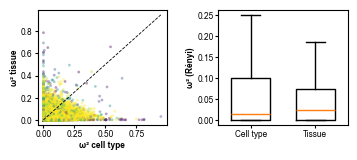

saved 05_01_variance_partition_diversity_renyi.pdf


In [5]:
# One figure PER ARM (was a single 3x2 grid), so each can be placed independently in the
# manuscript: the raw-R2 arm is supplementary, the df-adjusted composition arm is the main
# figure, and the diversity-level arm is supplementary again. Each figure keeps the same
# two panels as its old row: left = per-gene scatter (cell type vs tissue, y=x reference),
# right = boxplot of the same quantities across genes.
ARMS = [
    # (celltype col, tissue col, extra boxplot col, scatter axis label, boxplot y label,
    #  scatter title, boxplot title, output filename, split)
    #
    # `split` = (donor col, interaction col, unmodelled col) or None. Where present the arm
    # gets a THIRD panel breaking the residual open: the additive model's residual is
    # interaction + unmodelled, so panel 2 shows the residual as one bar and panel 3 shows what
    # it is made of. Only the RAW arms carry it -- omega^2 is a partial variance component, not
    # a partition, so it has no residual bar to split (see the note in anova_omega2_multi).
    ("omega2renyi_celltype", "omega2renyi_tissue", None, "ω²", "ω² (Rényi)",
     "Diversity level (ANOVA)", "Diversity-level explained",
     "05_01_variance_partition_diversity_renyi.pdf", None),
    # ("eta2_celltype", "eta2_tissue", "eta2_residual", "η²", "η² (Shannon)",
    #  "Diversity level (raw, Shannon)", "Variance explained (raw, Shannon)",
    #  "05_01_variance_partition_diversity_raw.pdf",
    #  ("eta2_donor", "eta2_interaction", "eta2_error")),
    # ("omega2_celltype", "omega2_tissue", None, "ω²", "ω² (entropy)",
    #  "Diversity level (ANOVA, Shannon)", "Diversity-level explained (Shannon)",
    #  "05_01_variance_partition_diversity.pdf", None),
]

for ct_col_, ti_col_, extra_col, ax_lab, box_lab, sc_title, box_title, fname, split in ARMS:
    # a split panel is only drawn if the columns exist AND some gene had a replicated
    # (celltype, tissue) cell; otherwise the arm falls back to the original two panels
    _sp = split if (split and all(col in res.columns for col in split)
                    and res[split[1]].notna().any()) else None
    fig, axes = plt.subplots(1, 2, figsize=(4.0, 1.5))

    ax = axes[0]
    ax.scatter(res[ct_col_], res[ti_col_], s=4, alpha=0.4, edgecolors="none",
               c=res["n_isoforms"].clip(upper=20), cmap="viridis")
    lim = max(res[ct_col_].max(), res[ti_col_].max())
    ax.plot([0, lim], [0, lim], "k--", lw=0.6)
    ax.set_xlabel(f"{ax_lab} cell type"); ax.set_ylabel(f"{ax_lab} tissue")
    # ax.set_title(sc_title, pad=PANEL_TITLE_PAD)

    # NAMING: the 'Unmodelled' bar is what remains AFTER the celltype-by-tissue interaction is
    # removed, so it is NOT the same quantity as eta2_residual / R2_residual, which are the
    # ADDITIVE model's residual (= interaction + this). Classical ANOVA would call it 'pure
    # error' (the within-cell term of a lack-of-fit split), but that overstates it: donor
    # interactions, tube/library effects and the three-way term all land in it and cannot be
    # separated under this design (tube is nested in (tissue, donor), so tissue-by-donor is
    # aliased with tube). 'Unmodelled' claims only what is true.
    #
    # Panel 2 is the FULL decomposition where the split is available. It strictly dominates the
    # old cell type / tissue / residual view: same cell-type and tissue values, plus DONOR (which
    # that view omitted even though donor is in the model, at ω² comparable to tissue), plus the
    # residual resolved into interaction + unmodelled. Restricting to genes with a replicated
    # (celltype, tissue) cell costs 6 of 10,850 genes. The old view is kept as the fallback for
    # arms/subsets where no split exists, so nothing is lost when replication is absent.
    ax = axes[1]
    if _sp:
        _don, _int, _unm = _sp
        _d = res[res[_int].notna()]
        ax.boxplot([_d[ct_col_], _d[ti_col_], _d[_don], _d[_int], _d[_unm]],
                   labels=["Cell type", "Tissue", "Donor", "Cell type\n× tissue", "Unmodelled"],
                   showfliers=False, widths=0.6)
        # ax.set_title(f"{box_title} ({len(_d):,} genes)", pad=PANEL_TITLE_PAD)
        plt.setp(ax.get_xticklabels(), rotation=90)
    else:
        cols = [res[ct_col_], res[ti_col_]] + ([res[extra_col]] if extra_col else [])
        labels = ["Cell type", "Tissue"] + (["Residual"] if extra_col else [])
        ax.boxplot(cols, labels=labels, showfliers=False, widths=0.6)
        # ax.set_title(box_title, pad=PANEL_TITLE_PAD)
    ax.set_ylabel(box_lab)

    plt.subplots_adjust(wspace=0.4)
    plt.savefig(figpath(fname))
    plt.show()
    print(f"saved {fname}" + (f"  [full decomposition, {len(_d):,} genes]" if _sp else ""))

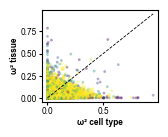

saved 05_01_variance_partition_diversity_renyi_scatter.pdf


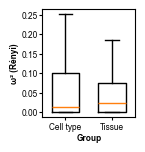

saved 05_01_variance_partition_diversity_renyi_boxplot.pdf


In [18]:
ARMS = [
    # (celltype col, tissue col, extra boxplot col, scatter axis label, boxplot y label,
    #  scatter title, boxplot title, output filename, split)
    #
    # `split` = (donor col, interaction col, unmodelled col) or None. Where present the arm
    # gets a THIRD panel breaking the residual open: the additive model's residual is interaction
    # + unmodelled. Only the RAW arms carry it -- omega^2 is a partial variance component, not
    # a partition, so it has no residual bar to split (see the note in anova_omega2_multi).
    ("omega2renyi_celltype", "omega2renyi_tissue", None, "ω²", "ω² (Rényi)",
     "Diversity level (ANOVA)", "Diversity-level explained",
     "05_01_variance_partition_diversity_renyi.pdf", None),
    # ("eta2_celltype", "eta2_tissue", "eta2_residual", "η²", "η² (Shannon)",
    #  "Diversity level (raw, Shannon)", "Variance explained (raw, Shannon)",
    #  "05_01_variance_partition_diversity_raw.pdf",
    #  ("eta2_donor", "eta2_interaction", "eta2_error")),
    # ("omega2_celltype", "omega2_tissue", None, "ω²", "ω² (entropy)",
    #  "Diversity level (ANOVA, Shannon)", "Diversity-level explained (Shannon)",
    #  "05_01_variance_partition_diversity.pdf", None),
]

for ct_col_, ti_col_, extra_col, ax_lab, box_lab, sc_title, box_title, fname, split in ARMS:

    # A split panel is only drawn if the columns exist AND some gene had a replicated
    # (celltype, tissue) cell; otherwise the arm falls back to the original two-panel version
    _sp = split if (split and all(col in res.columns for col in split)
                    and res[split[1]].notna().any()) else None

    # CHANGED: scatter panel is now its own figure
    fig, ax = plt.subplots(figsize=(1.5, 1.2))

    ax.scatter(res[ct_col_], res[ti_col_], s=4, alpha=0.4, edgecolors="none",
               c=res["n_isoforms"].clip(upper=20), cmap="viridis")
    lim = max(res[ct_col_].max(), res[ti_col_].max())
    ax.plot([0, lim], [0, lim], "k--", lw=0.6)
    ax.set_xlabel(f"{ax_lab} cell type")
    ax.set_ylabel(f"{ax_lab} tissue")
    # ax.set_title(sc_title, pad=PANEL_TITLE_PAD)
    scatter_fname = fname.replace(".pdf", "_scatter.pdf")
    plt.savefig(figpath(scatter_fname))
    plt.show()
    print(f"saved {scatter_fname}")

    # CHANGED: boxplot panel is now its own figure
    fig, ax = plt.subplots(figsize=(1.2, 1.4))

    # NAMING: the 'Unmodelled' bar is what remains AFTER the celltype-by-tissue interaction is
    # removed, so it is NOT the same quantity as eta2_residual / R2_residual, which are the
    # ADDITIVE model's residual (= interaction + this). Classical ANOVA would call it 'pure
    # error' (the within-cell term of a lack-of-fit split), but that overstates it: donor
    # interactions, tube/library effects and the three-way term all land in it and cannot be
    # separated under this design (tube is nested in (tissue, donor), so tissue-by-donor is
    # aliased with tube). 'Unmodelled' claims only what is true.
    #
    # The panel is the FULL decomposition where the split is available. It strictly dominates
    # the old cell type / tissue / residual view: same cell-type and tissue values, plus DONOR
    # (which that view omitted even though donor is in the model, at ω² comparable to tissue),
    # plus the residual resolved into interaction + unmodelled. Restricting to genes with a
    # replicated (celltype, tissue) cell costs 6 of 10,850 genes. The old view is kept as the
    # fallback for arms/subsets where no split exists, so nothing is lost when replication is
    # absent.
    if _sp:
        _don, _int, _unm = _sp
        _d = res[res[_int].notna()]
        ax.boxplot([_d[ct_col_], _d[ti_col_], _d[_don], _d[_int], _d[_unm]],
                   labels=["Cell type", "Tissue", "Donor", "Cell type\n× tissue", "Unmodelled"],
                   showfliers=False, widths=0.6)
        # ax.set_title(f"{box_title} ({len(_d):,} genes)", pad=PANEL_TITLE_PAD)
        plt.setp(ax.get_xticklabels(), rotation=90)
    else:
        cols = [res[ct_col_], res[ti_col_]] + ([res[extra_col]] if extra_col else [])
        labels = ["Cell type", "Tissue"] + (["Residual"] if extra_col else [])
        ax.boxplot(cols, labels=labels, showfliers=False, widths=0.6)
        # ax.set_title(box_title, pad=PANEL_TITLE_PAD)

    ax.set_ylabel(box_lab)
    ax.set_xlabel("Group")
    boxplot_fname = fname.replace(".pdf", "_boxplot.pdf")
    plt.savefig(figpath(boxplot_fname))
    plt.show()
    print(f"saved {boxplot_fname}" + (f"  [full decomposition, {len(_d):,} genes]" if _sp else ""))

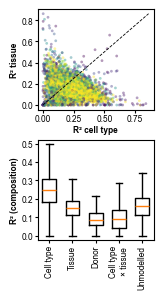

saved 05_01_variance_partition_composition_raw.pdf  [full decomposition, 10,846 genes]


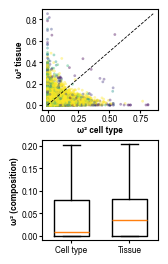

saved 05_01_variance_partition_composition_dfadj.pdf


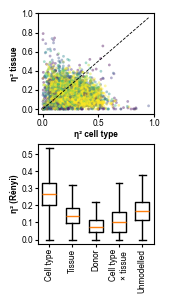

saved 05_01_variance_partition_diversity_renyi_raw.pdf  [full decomposition, 10,844 genes]


In [14]:
# One figure PER ARM (was a single 3x2 grid), so each can be placed independently in the
# manuscript: the raw-R2 arm is supplementary, the df-adjusted composition arm is the main
# figure, and the diversity-level arm is supplementary again. Each figure keeps the same
# two panels as its old row: left = per-gene scatter (cell type vs tissue, y=x reference),
# right = boxplot of the same quantities across genes.
ARMS = [
    # (celltype col, tissue col, extra boxplot col, scatter axis label, boxplot y label,
    #  scatter title, boxplot title, output filename, split)
    #
    # `split` = (donor col, interaction col, unmodelled col) or None. Where present the arm
    # gets a THIRD panel breaking the residual open: the additive model's residual is
    # interaction + unmodelled, so panel 2 shows the residual as one bar and panel 3 shows what
    # it is made of. Only the RAW arms carry it -- omega^2 is a partial variance component, not
    # a partition, so it has no residual bar to split (see the note in anova_omega2_multi).
    ("R2_celltype", "R2_tissue", "R2_residual", "R²", "R² (composition)",
     "Composition R² (raw)", "Variance explained (raw)",
     "05_01_variance_partition_composition_raw.pdf",
     ("R2_donor", "R2_interaction", "R2_error")),
    ("omega2comp_celltype", "omega2comp_tissue", None, "ω²", "ω² (composition)",
     "Composition ω² (df-adj.)", "Variance explained (df-adj.)",
     "05_01_variance_partition_composition_dfadj.pdf", None),
    ("eta2renyi_celltype", "eta2renyi_tissue", "eta2renyi_residual", "η²", "η² (Rényi)",
     "Diversity level (raw)", "Variance explained (raw)",
     "05_01_variance_partition_diversity_renyi_raw.pdf",
     ("eta2renyi_donor", "eta2renyi_interaction", "eta2renyi_error")),
    # ("eta2_celltype", "eta2_tissue", "eta2_residual", "η²", "η² (Shannon)",
    #  "Diversity level (raw, Shannon)", "Variance explained (raw, Shannon)",
    #  "05_01_variance_partition_diversity_raw.pdf",
    #  ("eta2_donor", "eta2_interaction", "eta2_error")),
    # ("omega2_celltype", "omega2_tissue", None, "ω²", "ω² (entropy)",
    #  "Diversity level (ANOVA, Shannon)", "Diversity-level explained (Shannon)",
    #  "05_01_variance_partition_diversity.pdf", None),
]

for ct_col_, ti_col_, extra_col, ax_lab, box_lab, sc_title, box_title, fname, split in ARMS:
    # a split panel is only drawn if the columns exist AND some gene had a replicated
    # (celltype, tissue) cell; otherwise the arm falls back to the original two panels
    _sp = split if (split and all(col in res.columns for col in split)
                    and res[split[1]].notna().any()) else None
    fig, axes = plt.subplots(2, 1, figsize=(1.5, 3.0))

    ax = axes[0]
    ax.scatter(res[ct_col_], res[ti_col_], s=4, alpha=0.4, edgecolors="none",
               c=res["n_isoforms"].clip(upper=20), cmap="viridis")
    lim = max(res[ct_col_].max(), res[ti_col_].max())
    ax.plot([0, lim], [0, lim], "k--", lw=0.6)
    ax.set_xlabel(f"{ax_lab} cell type"); ax.set_ylabel(f"{ax_lab} tissue")
    # ax.set_title(sc_title, pad=PANEL_TITLE_PAD)

    # NAMING: the 'Unmodelled' bar is what remains AFTER the celltype-by-tissue interaction is
    # removed, so it is NOT the same quantity as eta2_residual / R2_residual, which are the
    # ADDITIVE model's residual (= interaction + this). Classical ANOVA would call it 'pure
    # error' (the within-cell term of a lack-of-fit split), but that overstates it: donor
    # interactions, tube/library effects and the three-way term all land in it and cannot be
    # separated under this design (tube is nested in (tissue, donor), so tissue-by-donor is
    # aliased with tube). 'Unmodelled' claims only what is true.
    #
    # Panel 2 is the FULL decomposition where the split is available. It strictly dominates the
    # old cell type / tissue / residual view: same cell-type and tissue values, plus DONOR (which
    # that view omitted even though donor is in the model, at ω² comparable to tissue), plus the
    # residual resolved into interaction + unmodelled. Restricting to genes with a replicated
    # (celltype, tissue) cell costs 6 of 10,850 genes. The old view is kept as the fallback for
    # arms/subsets where no split exists, so nothing is lost when replication is absent.
    ax = axes[1]
    if _sp:
        _don, _int, _unm = _sp
        _d = res[res[_int].notna()]
        ax.boxplot([_d[ct_col_], _d[ti_col_], _d[_don], _d[_int], _d[_unm]],
                   labels=["Cell type", "Tissue", "Donor", "Cell type\n× tissue", "Unmodelled"],
                   showfliers=False, widths=0.6)
        # ax.set_title(f"{box_title} ({len(_d):,} genes)", pad=PANEL_TITLE_PAD)
        plt.setp(ax.get_xticklabels(), rotation=90)
    else:
        cols = [res[ct_col_], res[ti_col_]] + ([res[extra_col]] if extra_col else [])
        labels = ["Cell type", "Tissue"] + (["Residual"] if extra_col else [])
        ax.boxplot(cols, labels=labels, showfliers=False, widths=0.6)
        # ax.set_title(box_title, pad=PANEL_TITLE_PAD)
    ax.set_ylabel(box_lab)

    plt.subplots_adjust(hspace=0.3)
    plt.savefig(figpath(fname))
    plt.show()
    print(f"saved {fname}" + (f"  [full decomposition, {len(_d):,} genes]" if _sp else ""))

## 4. Resolution ladder — the cell-type isoform signal decays as annotation coarsens

The single-cell payoff, made explicit. We re-run the **identical** joint partition (df-adjusted composition ω² and diversity-level ω²) with the cell-type factor defined at progressively coarser resolution — **fine cell type (`cell_ontology_class`) → broad class (`broad_cell_class`)** — holding tissue fixed. As cell types are collapsed toward the tissue view, the cell-type ω² falls and the tissue ω² rises: isoform choice is written at the resolution of cell type and is only recoverable with single-cell data. (Pseudobulks stay at cell-type × tube level; this section rebuilds them per resolution, so it roughly doubles runtime — run on a compute node.)

In [7]:
# Resolution ladder: rerun the SAME joint partition with the cell-type factor at each
# resolution (tissue fixed). The per-gene partition is now PARALLELISED across a fork-based
# process pool (mirrors the main partition cell): genes are independent, so this is ~n_workers x
# faster than the old serial loop. Workers inherit `profiles` via copy-on-write; results are
# order-independent (only means / win-rates are taken), so numerically identical to serial.
import os, multiprocessing as _mp
from concurrent.futures import ProcessPoolExecutor
try:
    from threadpoolctl import threadpool_limits as _tpl
except Exception:
    from contextlib import nullcontext
    def _tpl(*a, **k):
        return nullcontext()

_LADDER = {}   # published per-resolution profiles for the fork workers

def _ladder_gene_chunk(g_list):
    profs_all = _LADDER["profiles"]
    out = []
    for g in g_list:
        profs = profs_all[g]
        if len(profs) < MIN_COMBOS:
            continue
        cts = [p[0] for p in profs]; tis_ = [p[1] for p in profs]
        if len(set(cts)) < 2 or len(set(tis_)) < 2:
            continue
        Y = np.asarray([p[2] for p in profs], dtype=float)
        C, T = dummies(cts), dummies(tis_)
        if len(profs) - 1 - C.shape[1] - T.shape[1] <= 0:
            continue
        pr = permanova_r2(Y, C, T)
        if pr is None:
            continue
        _, _, _, w2c_ct, w2c_ti = pr
        if w2c_ct is None:
            continue
        aw = anova_omega2(np.asarray([renyi(v) for v in Y]), C, T)
        if aw is None:
            continue
        w2_ct, w2_ti = aw
        out.append({"gene": unique_genes[g],
                    "omega2comp_celltype": w2c_ct, "omega2comp_tissue": w2c_ti,
                    "omega2_celltype": w2_ct, "omega2_tissue": w2_ti,
                    "n_celltypes": len(set(cts))})
    return out

def build_and_partition(ct_col):
    pop_ = adata.obs[ct_col].values
    cts_all = sorted(c for c in np.unique(pop_) if c != "unknown")
    profiles = {g: [] for g in range(n_genes_unique)}
    for ct in cts_all:
        ctm = (pop_ == ct)
        if ctm.sum() < MIN_CELLS_COMBO:
            continue
        for tube in tubes:                              # tube-level pseudobulk (replication)
            m = ctm & (tub == tube)
            if m.sum() < MIN_CELLS_COMBO:
                continue
            fr = frac_csr[m, :]
            cs = np.asarray(fr.sum(axis=0)).ravel()
            ge = (fr > 0).astype(np.float32) @ iso_to_gene
            npg = np.asarray((ge > 0).sum(axis=0)).ravel()
            ti = tube_tissue[tube]
            for g in np.where(npg >= MIN_CELLS_COMBO)[0]:
                cols = gene_col_indices[g]
                if len(cols) < MIN_ISOFORMS:
                    continue
                profiles[g].append((ct, ti, cs[cols] / npg[g]))
    # parallel per-gene partition (independent per gene; fork workers read `profiles`)
    _LADDER.clear(); _LADDER["profiles"] = profiles
    keys = [g for g, v in profiles.items() if len(v) >= MIN_COMBOS]
    nw = max(1, min(len(keys), len(os.sched_getaffinity(0)))) if keys else 1
    recs = []
    try:
        if nw <= 1 or len(keys) <= 1:
            recs = _ladder_gene_chunk(keys)
        else:
            chunks = [[int(g) for g in ch] for ch in np.array_split(keys, nw) if len(ch)]
            with _tpl(1), ProcessPoolExecutor(max_workers=nw, mp_context=_mp.get_context("fork")) as ex:
                for r in ex.map(_ladder_gene_chunk, chunks):
                    recs.extend(r)
    finally:
        _LADDER.clear()
    return pd.DataFrame(recs)


LADDER = [("Fine cell type\n(cell_ontology_class)", "cell_ontology_class"),
          ("Broad cell class\n(broad_cell_class)", "broad_cell_class")]
ladder_rows = []
for label, col in LADDER:
    d = build_and_partition(col)
    n = len(d)
    row = {
        "resolution": label, "ct_col": col, "n_genes": n,
        "n_celltype_levels": int(adata.obs[col].nunique()),
        "mean_omega2comp_celltype": d["omega2comp_celltype"].mean(),
        "mean_omega2comp_tissue": d["omega2comp_tissue"].mean(),
        "ct_win_frac_comp": float((d["omega2comp_celltype"] > d["omega2comp_tissue"]).mean()),
        "mean_omega2_celltype": d["omega2_celltype"].mean(),
        "mean_omega2_tissue": d["omega2_tissue"].mean(),
        "ct_win_frac_div": float((d["omega2_celltype"] > d["omega2_tissue"]).mean()),
    }
    ladder_rows.append(row)
    # diversity first: it is the reported arm (Renyi, matching Fig 4A/4B) and the one with a
    # clear direction; composition is the near-tie.
    print(f"[{col}] {n} genes, {row['n_celltype_levels']} cell-type levels")
    print(f"    diversity   ω² (Rényi): cell type {row['mean_omega2_celltype']:.3f} vs tissue "
          f"{row['mean_omega2_tissue']:.3f} (cell type wins {row['ct_win_frac_div']:.1%})")
    print(f"    composition ω²        : cell type {row['mean_omega2comp_celltype']:.3f} vs tissue "
          f"{row['mean_omega2comp_tissue']:.3f} (cell type wins {row['ct_win_frac_comp']:.1%})")

ladder_df = pd.DataFrame(ladder_rows)
ladder_df.to_csv(f"{CSVS_DIR}/celltype_vs_tissue_resolution_ladder.csv", index=False)

[cell_ontology_class] 13681 genes, 144 cell-type levels
    diversity   ω² (Rényi): cell type 0.053 vs tissue 0.042 (cell type wins 31.7%)
    composition ω²        : cell type 0.042 vs tissue 0.044 (cell type wins 27.2%)
[broad_cell_class] 14859 genes, 34 cell-type levels
    diversity   ω² (Rényi): cell type 0.045 vs tissue 0.083 (cell type wins 23.2%)
    composition ω²        : cell type 0.037 vs tissue 0.088 (cell type wins 17.9%)


,resolution,ct_col,n_genes,n_celltype_levels,mean_omega2comp_celltype,mean_omega2comp_tissue,ct_win_frac_comp,mean_omega2_celltype,mean_omega2_tissue,ct_win_frac_div
0,Fine cell type\n(cell_ontology_class),cell_ontology_class,13681,144,0.041771,0.043961,0.272422,0.052621,0.041587,0.316570
1,Broad cell class\n(broad_cell_class),broad_cell_class,14859,34,0.036967,0.088276,0.179016,0.044764,0.083162,0.232048


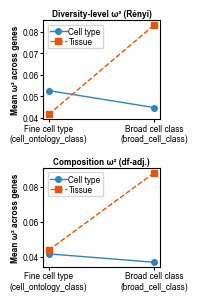

In [107]:
# Plot: mean ω² (cell type vs tissue) across the resolution ladder. Diversity on TOP
# (the reported arm, Rényi, matching Fig 4A/4B), composition below.
fig, axes = plt.subplots(2, 1, figsize=(1.5, 3.2))
x = np.arange(len(ladder_df))
for ax, (cc, tc, ttl) in zip(
        axes,
        [("mean_omega2_celltype", "mean_omega2_tissue", "Diversity-level ω² (Rényi)"),
         ("mean_omega2comp_celltype", "mean_omega2comp_tissue", "Composition ω² (df-adj.)")]):
    ax.plot(x, ladder_df[cc], "o-", color="#3182bd", lw=1, ms=4, label="Cell type")
    ax.plot(x, ladder_df[tc], "s--", color="#e6550d", lw=1, ms=4, label="Tissue")
    ax.set_xticks(x); ax.set_xticklabels(ladder_df["resolution"])
    ax.set_ylabel("Mean ω² across genes")
    ax.set_title(ttl, pad=PANEL_TITLE_PAD)
    ax.legend()
# fig.suptitle("Cell-type isoform signal decays as annotation coarsens", y=0.95)
plt.subplots_adjust(hspace = 0.5)
plt.savefig(figpath("05_01_resolution_ladder.pdf"))
# plt.show()
ladder_df

In [83]:
# Guard: `build` now emits 5-tuples (celltype, tissue, donor, tube, vector). If this cell
# is run against a kernel that still holds profiles from an older `build`, the workers
# fail with an opaque "tuple index out of range" from inside the process pool.
_ar = len(next(v[0] for v in gene_profiles.values() if v))
assert _ar == 5, (f"gene_profiles holds {_ar}-tuples, expected 5 -- re-run the `build` "
                  f"cell in section 1 before this one")

# Two-level corrected partition. Stage 1 estimates cell type within tube; stage 2 estimates
# tissue and donor between tubes. Reuses _hat / permanova_r2_multi / anova_omega2_multi.
def _two_level_one_gene(g, _profiles=None):
    # _profiles lets a restricted copy of the design reuse this worker unchanged
    profs = (gene_profiles if _profiles is None else _profiles)[g]
    if len(profs) < MIN_COMBOS:
        return None
    cts = [p[0] for p in profs]
    tis_ = [p[1] for p in profs]
    dons = [p[2] for p in profs]
    tubs_ = [p[3] for p in profs]
    Y = np.asarray([p[4] for p in profs], dtype=float)

    out = {"gene": unique_genes[g], "n_combos": len(profs), "n_isoforms": Y.shape[1],
           "n_celltypes": len(set(cts)), "n_tissues": len(set(tis_)),
           "n_donors": len(set(dons)), "n_tubes": len(set(tubs_))}

    # ---- stage 1: cell type WITHIN tube (tube absorbs library + tissue + donor) ----
    if len(set(cts)) >= 2 and len(set(tubs_)) >= 2:
        C, B = dummies(cts), dummies(tubs_)
        if len(profs) - 1 - C.shape[1] - B.shape[1] > 0:
            pr = permanova_r2_multi(Y, [C, B], ["celltype", "tube"])
            aw = anova_omega2_multi(np.asarray([renyi(v) for v in Y]), [C, B],
                                    ["celltype", "tube"])
            if pr is not None:
                out["omega2comp_celltype_wt"] = pr["omega2comp_celltype"]
                out["omega2comp_tube"] = pr["omega2comp_tube"]
                out["R2_residual_wt"] = pr["R2_residual"]
                out["df_residual_wt"] = pr["df_residual"]
            if aw is not None:
                out["omega2_celltype_wt"] = aw["omega2_celltype"]
                out["omega2_tube"] = aw["omega2_tube"]

    # ---- stage 2: tissue + donor BETWEEN tubes (one row per tube) ----
    tube_rows, tube_ti, tube_don = [], [], []
    for tb in sorted(set(tubs_)):
        idx = [i for i, t in enumerate(tubs_) if t == tb]
        tube_rows.append(Y[idx].mean(axis=0))
        tube_ti.append(tis_[idx[0]])
        tube_don.append(dons[idx[0]])
    Yt = np.asarray(tube_rows, dtype=float)
    if len(Yt) >= 4 and len(set(tube_ti)) >= 2:
        T, D = dummies(tube_ti), dummies(tube_don)
        if len(Yt) - 1 - T.shape[1] - D.shape[1] > 0:
            pr2 = permanova_r2_multi(Yt, [T, D], ["tissue", "donor"])
            aw2 = anova_omega2_multi(np.asarray([renyi(v) for v in Yt]), [T, D],
                                     ["tissue", "donor"])
            if pr2 is not None:
                out["omega2comp_tissue_bt"] = pr2["omega2comp_tissue"]
                out["omega2comp_donor_bt"] = pr2["omega2comp_donor"]
                out["R2_residual_bt"] = pr2["R2_residual"]
                out["df_residual_bt"] = pr2["df_residual"]
            if aw2 is not None:
                out["omega2_tissue_bt"] = aw2["omega2_tissue"]
                out["omega2_donor_bt"] = aw2["omega2_donor"]
    return out if ("omega2comp_celltype_wt" in out or "omega2comp_tissue_bt" in out) else None


def _two_level_chunk(g_list):
    return [r for r in (_two_level_one_gene(g) for g in g_list) if r is not None]


_keys2 = list(gene_profiles.keys())
_nw2 = max(1, min(len(_keys2), len(os.sched_getaffinity(0))))
_chunks2 = [[int(g) for g in c] for c in np.array_split(_keys2, _nw2) if len(c)]
print(f"two-level partition over {len(_keys2)} candidate genes on {_nw2} worker process(es)")

recs2 = []
with threadpool_limits(limits=1):
    if _nw2 == 1:
        for _ch in _chunks2:
            recs2.extend(_two_level_chunk(_ch))
    else:
        with ProcessPoolExecutor(max_workers=_nw2) as _ex:
            for _r in _ex.map(_two_level_chunk, _chunks2):
                recs2.extend(_r)

res2 = pd.DataFrame(recs2)
_out2 = f"{CSVS_DIR}/celltype_vs_tissue_two_level_partition.csv"
res2.to_csv(_out2, index=False)
print(f"genes with a stage-1 (within-tube) estimate : {res2['omega2comp_celltype_wt'].notna().sum():,}")
print(f"genes with a stage-2 (between-tube) estimate: {res2['omega2comp_tissue_bt'].notna().sum():,}")
print(f"saved {_out2}\n")

for arm, suff in (("composition", "omega2comp"), ("diversity", "omega2")):
    ct = res2[f"{suff}_celltype_wt"].dropna()
    ti = res2[f"{suff}_tissue_bt"].dropna()
    dn = res2[f"{suff}_donor_bt"].dropna()
    print(f"{arm:12s} cell type (within tube) {ct.mean():.4f}  n={len(ct):,} | "
          f"tissue (between tube) {ti.mean():.4f}  n={len(ti):,} | donor {dn.mean():.4f}")
print("\nNOTE the two stages are estimated on different units, so the numbers are NOT directly")
print("comparable as a single partition -- they are each factor's effect at its own level.")
print("Tissue remains aliased with library, so its value is an upper bound.")

two-level partition over 26940 candidate genes on 16 worker process(es)
genes with a stage-1 (within-tube) estimate : 12,014
genes with a stage-2 (between-tube) estimate: 13,024
saved ./../csvs/celltype_vs_tissue_two_level_partition.csv

composition  cell type (within tube) 0.1006  n=12,014 | tissue (between tube) 0.1656  n=13,024 | donor 0.0341
diversity    cell type (within tube) 0.1119  n=12,014 | tissue (between tube) 0.1922  n=13,024 | donor 0.0499

NOTE the two stages are estimated on different units, so the numbers are NOT directly
comparable as a single partition -- they are each factor's effect at its own level.
Tissue remains aliased with library, so its value is an upper bound.


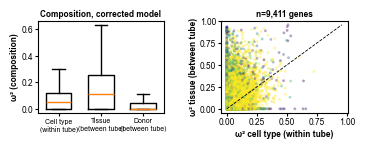

saved 05_01_two_level_partition_composition.pdf | cell type 0.1006 | tissue 0.1656 | donor 0.0341


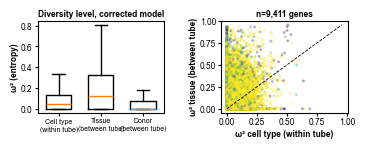

saved 05_01_two_level_partition_diversity.pdf | cell type 0.1119 | tissue 0.1922 | donor 0.0499


In [84]:
# Corrected-model figures: one per arm, cell type (within tube) beside tissue/donor
# (between tubes). Deliberately drawn as separate distributions rather than a shared
# partition, because the two stages are estimated on different units.
for arm, suff, ylab, fname in (
        ("Composition", "omega2comp", "ω² (composition)",
         "05_01_two_level_partition_composition.pdf"),
        ("Diversity level", "omega2", "ω² (entropy)",
         "05_01_two_level_partition_diversity.pdf")):
    cols = [res2[f"{suff}_celltype_wt"].dropna(),
            res2[f"{suff}_tissue_bt"].dropna(),
            res2[f"{suff}_donor_bt"].dropna()]
    labels = ["Cell type\n(within tube)", "Tissue\n(between tube)", "Donor\n(between tube)"]

    fig, axes = plt.subplots(1, 2, figsize=(4.0, 1.2))
    ax = axes[0]
    ax.boxplot(cols, labels=labels, showfliers=False, widths=0.6)
    ax.set_ylabel(ylab)
    ax.set_title(f"{arm}, corrected model", pad=PANEL_TITLE_PAD)
    ax.tick_params(axis="x", labelsize=5)

    # per-gene scatter for the genes that have both estimates
    ax = axes[1]
    both = res2[[f"{suff}_celltype_wt", f"{suff}_tissue_bt"]].dropna()
    ax.scatter(both[f"{suff}_celltype_wt"], both[f"{suff}_tissue_bt"], s=4, alpha=0.4,
               edgecolors="none", c=res2.loc[both.index, "n_isoforms"].clip(upper=20),
               cmap="viridis")
    lim = float(max(both.max())) if len(both) else 1.0
    ax.plot([0, lim], [0, lim], "k--", lw=0.6)
    ax.set_xlabel("ω² cell type (within tube)")
    ax.set_ylabel("ω² tissue (between tube)")
    ax.set_title(f"n={len(both):,} genes", pad=PANEL_TITLE_PAD)

    plt.subplots_adjust(wspace=0.45)
    plt.savefig(figpath(fname))
    plt.show()
    print(f"saved {fname} | cell type {cols[0].mean():.4f} | tissue {cols[1].mean():.4f} | "
          f"donor {cols[2].mean():.4f}")

### 5b. Restricted to cell types spanning >= 5 tissues

Same two-level model, run on the subset of cell types observed in at least 5 distinct tissues
**for that gene**. The filter is per gene, not global: a cell type sampled from many tissues
atlas-wide may still occupy few tissues for a sparsely expressed gene, and it is the per-gene
design that determines what is estimable.

Note what this does and does not do under the corrected model. In the two-factor fit, the
restriction was about **identifiability** -- 68% of cell types sit in a single tissue and were
aliased with it (that 68% was measured with FINE cell types; with `broad_cell_class` as
`CT_COL` the aliasing is far milder -- the printout below reports the actual surviving count
for whichever resolution is in use). Stage 1 of the corrected model already removes that
problem a different way,
by blocking on tube: a single-tissue cell type is still compared against the other cell types
*in its own tube*, so it contributes legitimately. So here the restriction is no longer an
identifiability fix but a **composition question**: is the cell-type signal carried by the
broadly distributed populations (macrophage, T/NK/B, endothelial, fibroblast), or by the
tissue-restricted specialists that the filter removes?

Expect a steep cut -- at >= 5 tissues only a small minority of cell types survive, and genes
need `MIN_COMBOS` profiles remaining afterwards. The printout reports both, so the shrinkage
is visible rather than silent.

In [50]:
# Restricted two-level partition: cell types in >= MIN_TISSUES_PER_CT tissues for that gene.
from collections import defaultdict
from functools import partial

MIN_TISSUES_PER_CT = 5

_ar = len(next(v[0] for v in gene_profiles.values() if v))
assert _ar == 5, f"gene_profiles holds {_ar}-tuples, expected 5 -- re-run the `build` cell"


def _restrict_profs(profs):
    seen = defaultdict(set)
    for ct, ti, _dn, _tb, _v in profs:
        seen[ct].add(ti)
    keep = {ct for ct, s in seen.items() if len(s) >= MIN_TISSUES_PER_CT}
    return [p for p in profs if p[0] in keep]


gene_profiles_r5 = {g: _restrict_profs(v) for g, v in gene_profiles.items()}

# how much of the design survives
_span = defaultdict(set)
for v in gene_profiles.values():
    for ct, ti, _dn, _tb, _v in v:
        _span[ct].add(ti)
_kept_ct = sorted(ct for ct, s in _span.items() if len(s) >= MIN_TISSUES_PER_CT)
print(f"cell types spanning >= {MIN_TISSUES_PER_CT} tissues: {len(_kept_ct)} of {len(_span)}")
print("  " + ", ".join(_kept_ct[:15]) + (" ..." if len(_kept_ct) > 15 else ""))
print(f"genes retaining >= MIN_COMBOS profiles after the filter: "
      f"{sum(1 for v in gene_profiles_r5.values() if len(v) >= MIN_COMBOS):,}")


def _two_level_chunk_r5(g_list):
    f = partial(_two_level_one_gene, _profiles=gene_profiles_r5)
    return [r for r in (f(g) for g in g_list) if r is not None]


_keys5 = list(gene_profiles_r5.keys())
_nw5 = max(1, min(len(_keys5), len(os.sched_getaffinity(0))))
_chunks5 = [[int(g) for g in c] for c in np.array_split(_keys5, _nw5) if len(c)]
recs5 = []
with threadpool_limits(limits=1):
    if _nw5 == 1:
        for _ch in _chunks5:
            recs5.extend(_two_level_chunk_r5(_ch))
    else:
        with ProcessPoolExecutor(max_workers=_nw5) as _ex:
            for _r in _ex.map(_two_level_chunk_r5, _chunks5):
                recs5.extend(_r)

res5 = pd.DataFrame(recs5)
_out5 = f"{CSVS_DIR}/celltype_vs_tissue_two_level_ct_ge{MIN_TISSUES_PER_CT}tissues.csv"
res5.to_csv(_out5, index=False)
print(f"\ngenes with a stage-1 estimate: "
      f"{int(res5['omega2comp_celltype_wt'].notna().sum()) if len(res5) else 0:,} "
      f"(unrestricted: {int(res2['omega2comp_celltype_wt'].notna().sum()):,})")
print(f"saved {_out5}\n")

for arm, suff in (("composition", "omega2comp"), ("diversity", "omega2")):
    for lab, df in (("all cell types", res2), (f">= {MIN_TISSUES_PER_CT} tissues", res5)):
        if not len(df):
            continue
        ct = df[f"{suff}_celltype_wt"].dropna()
        ti = df[f"{suff}_tissue_bt"].dropna()
        print(f"  {arm:12s} {lab:18s} cell type (within tube) {ct.mean():.4f} n={len(ct):,} | "
              f"tissue (between tube) {ti.mean():.4f} n={len(ti):,}")
print("\nA cell-type mean that holds up under the filter means the signal is carried by the")
print("broadly distributed populations; a drop means it came from tissue-restricted specialists.")

cell types spanning >= 5 tissues: 17 of 122
  b cell, cd4-positive, alpha-beta t cell, cd8-positive, alpha-beta t cell, classical monocyte, endothelial cell, endothelial cell of lymphatic vessel, erythrocyte, fibroblast, macrophage, mast cell, mature nk t cell, monocyte, natural killer cell, neutrophil, pericyte ...
genes retaining >= MIN_COMBOS profiles after the filter: 12,064

genes with a stage-1 estimate: 9,289 (unrestricted: 12,014)
saved ./../csvs/celltype_vs_tissue_two_level_ct_ge5tissues.csv

  composition  all cell types     cell type (within tube) 0.1006 n=12,014 | tissue (between tube) 0.1656 n=13,024
  composition  >= 5 tissues       cell type (within tube) 0.0570 n=9,289 | tissue (between tube) 0.0667 n=7,126
  diversity    all cell types     cell type (within tube) 0.1144 n=12,014 | tissue (between tube) 0.1996 n=13,024
  diversity    >= 5 tissues       cell type (within tube) 0.0592 n=9,289 | tissue (between tube) 0.1156 n=7,126

A cell-type mean that holds up under the

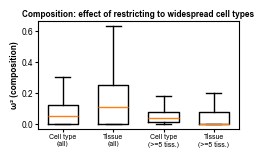

saved 05_01_two_level_restricted_composition.pdf | Cell type (all) 0.1006 | Tissue (all) 0.1656 | Cell type (>=5 tiss.) 0.0570 | Tissue (>=5 tiss.) 0.0667


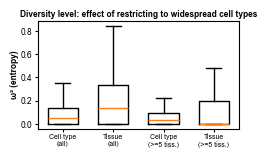

saved 05_01_two_level_restricted_diversity.pdf | Cell type (all) 0.1144 | Tissue (all) 0.1996 | Cell type (>=5 tiss.) 0.0592 | Tissue (>=5 tiss.) 0.1156


In [51]:
# Restricted vs unrestricted, side by side, for each arm.
for arm, suff, ylab, fname in (
        ("Composition", "omega2comp", "ω² (composition)",
         "05_01_two_level_restricted_composition.pdf"),
        ("Diversity level", "omega2", "ω² (entropy)",
         "05_01_two_level_restricted_diversity.pdf")):
    cols, labels = [], []
    for lab, df in (("all", res2), (f">={MIN_TISSUES_PER_CT} tiss.", res5)):
        if not len(df):
            continue
        cols += [df[f"{suff}_celltype_wt"].dropna(), df[f"{suff}_tissue_bt"].dropna()]
        labels += [f"Cell type\n({lab})", f"Tissue\n({lab})"]

    fig, ax = plt.subplots(figsize=(2.6, 1.4))
    ax.boxplot(cols, labels=labels, showfliers=False, widths=0.6)
    ax.set_ylabel(ylab)
    ax.set_title(f"{arm}: effect of restricting to widespread cell types", pad=PANEL_TITLE_PAD)
    ax.tick_params(axis="x", labelsize=5)
    plt.savefig(figpath(fname))
    plt.show()
    print(f"saved {fname} | " + " | ".join(f"{l.replace(chr(10),' ')} {c.mean():.4f}"
                                           for l, c in zip(labels, cols)))